# Actor-Critic Methods in Reinforcement Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement actor–critic algorithms
- Combine policy and value learning

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces the **actor-critic** idea: one part of the system chooses actions, and another estimates how good states or actions are.

Students will see why combining a policy learner with a value estimator can reduce variance and make learning more stable.

Why this matters: actor-critic methods are the foundation of many practical RL algorithms used in continuous control and modern AI systems.

This lesson is a bridge from basic policy gradients to stronger methods like PPO.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Actor: chooses actions.
- Critic: judges actions or states.
- Advantage-like signal: tells whether an action was better than expected.
- Shared loop: both learn from the same experience.

### Quick Check
- What does the actor learn?
- What does the critic learn?
- Why can this be more stable than pure policy gradients?

### Common Mistakes
- Swapping actor and critic roles.
- Thinking the critic chooses actions.
- Forgetting they optimize different objectives.


# Actor-Critic Methods in Reinforcement Learning
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Understand Actor-Critic architecture
- Implement Actor-Critic algorithm
- Apply to continuous control tasks
- Compare with value-based methods

## Real-World Context

Robotics control, autonomous systems, and continuous action spaces.

**Industry Impact**: Used in robotics, autonomous vehicles, and game AI.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

%pip install "gymnasium[classic_control]" torch numpy matplotlib -q
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
print('✅ Setup complete!')

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Actor-Critic Architecture


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

class ActorCritic(nn.Module):
    def __init__(self, obs_dim=4, act_dim=2):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
        )
        self.actor_head = nn.Linear(128, act_dim)
        self.critic_head = nn.Linear(128, 1)

    def forward(self, x):
        features = self.shared(x)
        policy_logits = self.actor_head(features)
        state_value = self.critic_head(features)
        return policy_logits, state_value


## Part 2: Training Loop


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def train_actor_critic(env_name='CartPole-v1', episodes=5):
    """Minimal demonstration loop structure for actor-critic training."""
    env = gym.make(env_name)
    model = ActorCritic()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for episode in range(episodes):
        obs, _ = env.reset()
        total_reward = 0
        for _ in range(200):
            obs_t = torch.tensor(obs).float().unsqueeze(0)
            logits, value = model(obs_t)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            next_obs, reward, done, trunc, _ = env.step(action.item())

            with torch.no_grad():
                _, next_value = model(torch.tensor(next_obs).float().unsqueeze(0))
            target = reward + 0.99 * next_value.item() * (0 if (done or trunc) else 1)
            advantage = target - value.item()

            actor_loss = -dist.log_prob(action) * advantage
            critic_loss = (value.squeeze() - target) ** 2
            loss = actor_loss + critic_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            obs = next_obs
            total_reward += reward
            if done or trunc:
                break
        print(f"Episode {episode + 1}: reward={total_reward}")

    env.close()
    return model


_ = train_actor_critic(episodes=3)

Episode 1: reward=16.0
Episode 2: reward=17.0
Episode 3: reward=11.0


## Real-World Applications

- **Robotics**: Continuous control (robot arm, walking)
- **Autonomous Vehicles**: Steering, acceleration control
- **Game AI**: Real-time strategy games
- **Finance**: Portfolio optimization

---

**End of Notebook**

## 🌍 Real-World Worked Example — REINFORCE on CartPole

**Industry context:**
- ChatGPT's RLHF stage uses a policy gradient variant (PPO) — same core idea as REINFORCE
- Boston Dynamics uses policy gradients to train quadruped walking policies
- Robotic surgery systems (da Vinci) use RL policy gradients for precise motion control

We implement **REINFORCE** (the simplest policy gradient) on CartPole-v1.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Episode   0 | Avg reward: 19.0


Episode  50 | Avg reward: 29.3


Episode 100 | Avg reward: 58.7


Episode 150 | Avg reward: 114.3


Episode 200 | Avg reward: 218.1


Episode 250 | Avg reward: 233.9


Episode 300 | Avg reward: 168.9


Episode 350 | Avg reward: 161.8


Episode 400 | Avg reward: 431.8


Episode 450 | Avg reward: 305.2


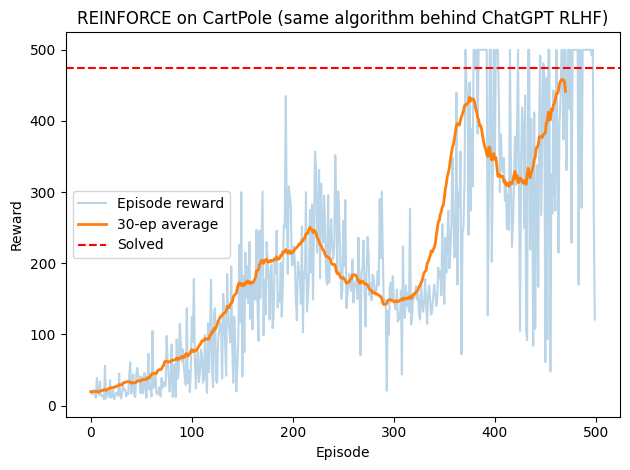

In [4]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)
env = gym.make('CartPole-v1')

class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        )
    def forward(self, x): return self.net(x)

policy  = PolicyNet()
opt     = optim.Adam(policy.parameters(), lr=2e-3)
GAMMA   = 0.99; ep_rewards = []

for episode in range(500):
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    for _ in range(500):
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        dist   = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, r, done, trunc, _ = env.step(action.item())
        rewards_ep.append(r)
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    G = 0; returns = []
    for r in reversed(rewards_ep):
        G = r + GAMMA*G; returns.insert(0, G)
    returns = torch.tensor(returns).float()
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    opt.zero_grad(); loss.backward(); opt.step()
    ep_rewards.append(sum(rewards_ep))
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

env.close()
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
plt.plot(ep_rewards, alpha=0.3, label="Episode reward")
plt.plot(ma, lw=2, label="30-ep average")
plt.axhline(475, color='red', linestyle='--', label="Solved")
plt.title("REINFORCE on CartPole (same algorithm behind ChatGPT RLHF)")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout(); plt.show()

## 📚 References & Further Reading

**Papers:**
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

**State-of-the-Art:**
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control

## 📝 Summary

You learned **Policy Gradient** methods that directly optimize the policy without a value table. **Actor-Critic** combines a policy (actor) with a value estimator (critic) for lower variance. **PPO** is today's most-used algorithm — it powers OpenAI's ChatGPT RLHF training and robotics at Boston Dynamics.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


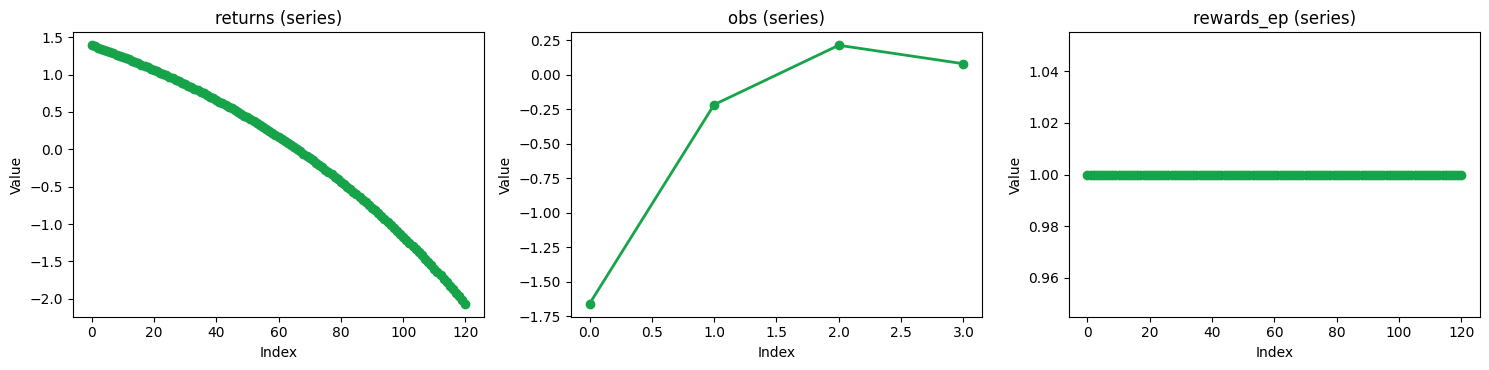

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Actor-critic methods combine a policy learner with a value-based guide so each part supports the other during training.

**If students remember one idea:** The actor decides what to do, while the critic evaluates how good the decision appears to be.

**Quick check before moving on:**
- Can you explain the separate jobs of the actor and the critic?
- Can you describe why the critic can reduce variance in policy learning?

**Bridge to the next step:** This prepares students for PPO, which adds practical constraints that make policy optimization more stable.
